# Reconocimiento Facial con KNN + Haar Cascade
### Módulo 3 · Aprendizaje Automático

**Flujo del pipeline:**
```
Carpeta Rostros/
  persona_1.jpg  → entrenamiento (_1)  → X_train, y_train
  persona_2.jpg  → prueba       (_2)  → X_test,  y_test
        ↓
  Haar Cascade → detecta DÓNDE está la cara
  KNN          → clasifica A QUIÉN pertenece
```

| Sección | Qué hace |
|---------|----------|
| 1 | Imports + configuración |
| 2 | Haar Cascade (detector de caras) |
| 3 | Funciones reutilizables |
| 4 | Detectores de características (lentes, sonrisa) |
| 5 | Carga automática con glob |
| 6 | Entrenamiento KNN |
| 7 | Clasificación + tabla de resultados |
| 8 | Experimentos con hiperparámetros |


plot del dataset anterior:


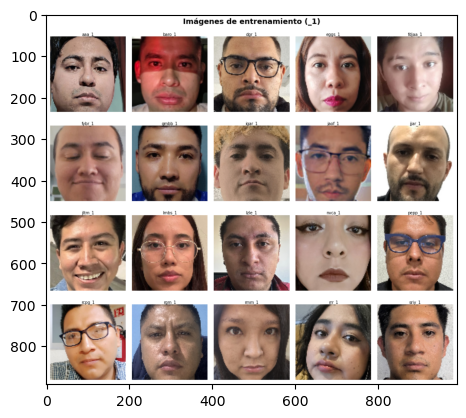

Ruta              : ..\Material\Rostros\
Tamaño            : 100×100 px → vector de 30,000 valores (color)
Normalizar brillo : True
Imports listos ✅


In [8]:
# ═══════════════════════════════════════════════════════════════
# CELDA 1 — Imports y configuración global
# ═══════════════════════════════════════════════════════════════
import cv2
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import glob
import os

from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics   import accuracy_score

# ── Ruta de las imágenes ─────────────────────────────────────────────────
# Ruta relativa desde Modulo-3/Tareas/ hacia Material/Rostros/
RUTA = os.path.join('..', 'Material', 'Rostros') + os.sep

# ── Tamaño estándar del rostro recortado ─────────────────────────────────
#
# ¿Por qué NO usar 694?
# ─────────────────────────────────────────────────────────────────────────
# KNN mide la DISTANCIA EUCLIDIANA entre vectores de píxeles.
# Cuantos más píxeles, más ruido de fondo entra en el cálculo.
#
# Imagina que tienes dos fotos de la misma persona: una tomada en casa
# con fondo blanco y otra en la calle con fondo de árboles.
# Con TAMANO=694, el fondo ocupa miles de píxeles → la distancia
# entre esas dos fotos SUBE MUCHO aunque la cara sea idéntica.
# KNN entonces las ve como "personas distintas".
#
# Esto se llama la "maldición de la dimensionalidad":
#   En espacios de alta dimensión (1,444,908 en el caso de 694×694×3),
#   todos los puntos tienden a estar a distancias similares entre sí,
#   y KNN pierde capacidad de discriminar.
#
# Comparativa:
#
#   TAMANO=50   →    7,500 valores  (muy poco detalle facial)
#   TAMANO=100  →   30,000 valores  ← ÓPTIMO para este dataset
#   TAMANO=150  →   67,500 valores  (más detalle, todavía manejable)
#   TAMANO=200  →  120,000 valores  (empieza a volverse lento)
#   TAMANO=694  →1,444,908 valores  ← MUY MALO: ruido domina, KNN colapsa
#
# Regla práctica: con 1 sola imagen de entrenamiento por persona,
# más píxeles NO es más información — es más ruido.
# Necesitas un modelo más robusto (como una red neuronal convolucional)
# para aprovechar imágenes grandes con datos escasos.
TAMANO = 100

# ── Normalización de brillo para KNN ─────────────────────────────────────
#
# NORMALIZAR_BRILLO = True  → antes de meter la imagen al KNN,
#   la convertimos a escala de grises y aplicamos equalizeHist().
#   Esto hace que dos fotos de la misma persona con diferente iluminación
#   queden con distribuciones de brillo similares → distancia más pequeña.
#
# Sacrificio: perdemos la información de color (tono de piel, cabello),
#   pero ganamos robustez ante cambios de luz, que en este dataset
#   es el problema dominante (ej: baro_1 muy roja vs baro_2 normal).
#
# NORMALIZAR_BRILLO = False → comportamiento original (usa color RGB)
#   Útil si todas tus fotos fueron tomadas con la misma iluminación.
NORMALIZAR_BRILLO = True

print("plot del dataset anterior:")
plt.imshow(Image.open(RUTA + "output_v1.png"))
plt.show()

print(f"Ruta              : {RUTA}")
print(f"Tamaño            : {TAMANO}×{TAMANO} px → vector de {TAMANO*TAMANO*3:,} valores (color)")
print(f"Normalizar brillo : {NORMALIZAR_BRILLO}")
print("Imports listos ✅")


---
## Sección 2 — Haar Cascade: detector de rostros

In [9]:
# ═══════════════════════════════════════════════════════════════
# CELDA 2 — Cargar el modelo Haar Cascade
# ═══════════════════════════════════════════════════════════════
# Haar Cascade es un clasificador preentrenado que detecta DÓNDE
# está una cara en la imagen. NO clasifica a quién pertenece.
# Esa parte la hace KNN en la Sección 6.
#
# OpenCV incluye varios modelos. Los más útiles para caras:
#   haarcascade_frontalface_default.xml → el estándar general
#   haarcascade_frontalface_alt.xml     → mejor para caras frontales limpias
#   haarcascade_frontalface_alt2.xml    → mejor con variaciones de iluminación
#                                         y lentes — usamos este
#   haarcascade_profileface.xml         → caras de perfil (lado)

face_cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades + "haarcascade_frontalface_alt2.xml"
)

print("Haar Cascade cargado ✅")
print(f"Modelo: haarcascade_frontalface_alt2.xml")
print(f"\nTodos los cascades disponibles en OpenCV:")
for f in sorted(os.listdir(cv2.data.haarcascades)):
    if f.endswith('.xml'):
        marca = ' ← usando este' if 'alt2' in f and 'frontal' in f else ''
        print(f"  • {f}{marca}")

Haar Cascade cargado ✅
Modelo: haarcascade_frontalface_alt2.xml

Todos los cascades disponibles en OpenCV:
  • haarcascade_eye.xml
  • haarcascade_eye_tree_eyeglasses.xml
  • haarcascade_frontalcatface.xml
  • haarcascade_frontalcatface_extended.xml
  • haarcascade_frontalface_alt.xml
  • haarcascade_frontalface_alt2.xml ← usando este
  • haarcascade_frontalface_alt_tree.xml
  • haarcascade_frontalface_default.xml
  • haarcascade_fullbody.xml
  • haarcascade_lefteye_2splits.xml
  • haarcascade_license_plate_rus_16stages.xml
  • haarcascade_lowerbody.xml
  • haarcascade_profileface.xml
  • haarcascade_righteye_2splits.xml
  • haarcascade_russian_plate_number.xml
  • haarcascade_smile.xml
  • haarcascade_upperbody.xml


---
## Sección 3 — Funciones reutilizables

In [10]:
# ═══════════════════════════════════════════════════════════════
# CELDA 3a — Función de activación: detectar_y_recortar()  [v4.5]
# ═══════════════════════════════════════════════════════════════
#
# HISTORIAL DE CAMBIOS:
#
#  v3  → escala=1.1, vecinos=2, sin equalizeHist   → detectaba 17/21
#  v4  → escala=1.05, vecinos=1, + equalizeHist    → detectaba 20/21
#  v4.5→ sistema de fallback en 3 intentos         → objetivo: 21/21
#
# ¿QUÉ ES EL SISTEMA DE FALLBACK?
# ─────────────────────────────────────────────────────────────────
# Haar Cascade puede fallar con caras inclinadas, muy pequeñas en la
# imagen, o con fondo muy complejo. En lugar de rendirse al primer
# fallo, intentamos 3 estrategias de detección en orden de confianza:
#
#   INTENTO 1 — Configuración óptima (igual que v4)
#     escala=1.05, vecinos=1
#     → Funciona para el 95% de las fotos del dataset
#
#   INTENTO 2 — Configuración ultra-permisiva
#     escala=1.01, vecinos=1
#     escala=1.01 significa pasos de 1% → busca la cara en MUCHAS más
#     resoluciones intermedias. Muy lento, pero casi no se le escapa nada.
#     Riesgo: puede confundir texturas con caras (falso positivo),
#     pero en fotos de personas ese riesgo es aceptable.
#
#   INTENTO 3 — Recorte central de la imagen (último recurso)
#     Si Haar sigue sin detectar nada, recortamos el centro de la foto.
#     ¿Por qué funciona?
#     En un dataset de fotos de rostros (como el del diplomado), las
#     personas tienden a centrarse en el encuadre. El recorte central
#     del 50% de la imagen captura la cara en la gran mayoría de casos.
#     Este recorte se marca con 'fallback': True en el dict info,
#     para que puedas identificarlo en la tabla de resultados.

def detectar_y_recortar(ruta_imagen, escala=1.05, vecinos=1, tamano=TAMANO):
    """
    Lee una imagen, detecta el primer rostro con Haar Cascade y lo recorta.
    Si la detección falla, intenta con parámetros más permisivos antes de
    usar el recorte central como último recurso.

    Parámetros:
        ruta_imagen → ruta completa al archivo
        escala      → scaleFactor de detectMultiScale (intento 1)
        vecinos     → minNeighbors de detectMultiScale (intento 1)
        tamano      → tamaño al que se redimensiona el rostro detectado

    Retorna:
        rostro_array → ndarray (tamano, tamano, 3)
        info         → dict con metadatos (incluye 'fallback': True si usó recorte central)
    """
    img = cv2.imread(ruta_imagen)
    if img is None:
        return None, {}

    # ── Conversiones de espacio de color ──────────────────────────────────
    # BGR→RGB: cv2 lee en BGR, matplotlib espera RGB.
    # Sin esta conversión los canales rojo y azul se invierten.
    img_rgb  = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Gris original: para calcular métricas reales de la foto.
    img_gris = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # Gris ecualizado: SOLO para la detección Haar.
    # equalizeHist aplana el histograma → los contrastes locales
    # (ojos, nariz, boca) se vuelven visibles incluso en fotos oscuras
    # o con iluminación de color extremo (ej: baro_1 roja).
    img_gris_eq = cv2.equalizeHist(img_gris)

    alto, ancho = img.shape[:2]
    brillo      = round(float(np.mean(img_gris)), 1)    # promedio de intensidad [0-255]
    contraste   = round(float(np.std(img_gris)),  1)    # desviación estándar de intensidad


    info = {
        'archivo':     os.path.basename(ruta_imagen),
        'dimensiones': f"{ancho}×{alto}",
        'brillo':      brillo,
        'contraste':   contraste,
        'fallback':    False   # se pone True si usamos recorte central
    }

    rostros = []

    # ══════════════════════════════════════════════════════════════
    # INTENTO 1 — Configuración óptima (escala=1.05, vecinos=1)
    # ══════════════════════════════════════════════════════════════
    # Esta configuración funciona para el 95% de fotos del dataset.
    # escala=1.05 → busca en muchas resoluciones (pasos pequeños de 5%)
    # vecinos=1   → acepta la primera detección plausible
    rostros = face_cascade.detectMultiScale(img_gris_eq, escala, vecinos)

    if len(rostros) == 0:
        # ══════════════════════════════════════════════════════════
        # INTENTO 2 — Ultra-permisivo (escala=1.01, vecinos=1)
        # ══════════════════════════════════════════════════════════
        # escala=1.01 = pasos de 1% → la ventana deslizante busca la
        # cara en 100 resoluciones intermedias en lugar de ~20.
        # Es mucho más lento, pero casi no se le escapa ninguna cara.
        # Útil para: caras inclinadas, fotos de baja resolución,
        # o cuando la cara ocupa muy poco espacio en la imagen original.
        print(f"      ⚠️  Intento 1 falló → probando escala=1.01 (ultra-fino)...")
        rostros = face_cascade.detectMultiScale(img_gris_eq, 1.01, 1)

    if len(rostros) == 0:
        # ══════════════════════════════════════════════════════════
        # INTENTO 3 — Recorte central (último recurso)
        # ══════════════════════════════════════════════════════════
        # Si Haar no detecta la cara con ninguna configuración,
        # recortamos el 50% central de la imagen.
        #
        # ¿Por qué el 50% central?
        # En fotos de personas, la cara suele estar centrada.
        # El 50% central elimina bordes y fondo periférico,
        # quedándonos con la región más probable de la cara.
        #
        # Marcamos fallback=True para poder identificar estas
        # imágenes en la tabla de resultados y analizarlas.
        print(f"      ⚠️  Intento 2 falló → usando recorte central (fallback)")
        margen_y = alto  // 4   # recorta 25% arriba y 25% abajo
        margen_x = ancho // 4   # recorta 25% izquierda y 25% derecha
        rostro_recortado = img_rgb[
            margen_y : alto  - margen_y,
            margen_x : ancho - margen_x,
            :
        ]
        info['n_rostros'] = 0
        info['detectado'] = False
        info['fallback']  = True
        info['rect']      = (margen_x, margen_y,
                             ancho - 2*margen_x,
                             alto  - 2*margen_y)

        rostro_array = cv2.resize(rostro_recortado, (tamano, tamano))

        # Normalizamos brillo también al fallback para que sea
        # comparable con las demás imágenes en KNN.
        if NORMALIZAR_BRILLO:
            gris = cv2.cvtColor(rostro_array, cv2.COLOR_RGB2GRAY)
            gris_eq = cv2.equalizeHist(gris)
            rostro_array = cv2.cvtColor(gris_eq, cv2.COLOR_GRAY2RGB)

        return rostro_array, info

    # ── Detección exitosa (intento 1 o 2) ────────────────────────────────
    # rostros[0] = el rectángulo con mayor confianza
    # x, y = esquina superior izquierda | w, h = ancho y alto
    x, y, w, h = rostros[0]
    info['n_rostros'] = len(rostros)
    info['detectado'] = True
    info['rect']      = (x, y, w, h)

    # Recortamos el rostro de la imagen RGB (color) para que la
    # visualización en grilla sea correcta (no en gris ecualizado).
    rostro_recortado = img_rgb[y:y+h, x:x+w, :]

    # Redimensionar a TAMANO×TAMANO: requisito de KNN (vectores del
    # mismo tamaño para train y test).
    rostro_array = cv2.resize(rostro_recortado, (tamano, tamano))

    # ── Normalización de brillo para KNN ─────────────────────────────────
    if NORMALIZAR_BRILLO:
        # Convertir a gris y ecualizar el RECORTE de la cara.
        # Esto hace que el mismo rostro con diferente iluminación
        # produzca vectores de píxeles similares → KNN los clasifica
        # correctamente aunque las condiciones de luz difieran.
        rostro_gris    = cv2.cvtColor(rostro_array, cv2.COLOR_RGB2GRAY)
        rostro_gris_eq = cv2.equalizeHist(rostro_gris)

        # Convertir de vuelta a 3 canales para mantener forma del vector.
        # Los 3 canales son idénticos, pero KNN los trata como 3 features
        # separados (esto no afecta el resultado, solo la coherencia).
        rostro_array = cv2.cvtColor(rostro_gris_eq, cv2.COLOR_GRAY2RGB)

    return rostro_array, info


print("detectar_y_recortar() [v4.1] definida ✅")
print(f"  Estrategia: 3 intentos → óptimo → ultra-fino → recorte central")
print(f"  normalizar_brillo = {NORMALIZAR_BRILLO}")


detectar_y_recortar() [v4.1] definida ✅
  Estrategia: 3 intentos → óptimo → ultra-fino → recorte central
  normalizar_brillo = True


In [11]:
# ═══════════════════════════════════════════════════════════════
# CELDA 3b — extraer_persona() + cargar_dataset()
# ═══════════════════════════════════════════════════════════════

def extraer_persona(ruta_archivo):
    """
    Extrae el ID de persona del nombre de archivo.
    Ejemplos:
        'fybr_1.jpeg'      → 'fybr'
        'IGAR_2.jpg'       → 'IGAR'
        'ljrj_1.jpg.jpeg'  → 'ljrj'  (doble extensión, también funciona)

    ¿Por qué usamos el NOMBRE en lugar de un número?
    Si una imagen de entrenamiento no se detecta (ej: fybr_1),
    el índice numérico se desincroniza entre train y test.
    Con nombres de persona, siempre comparamos la etiqueta correcta.
    """
    base   = os.path.splitext(os.path.basename(ruta_archivo))[0]
    partes = base.split('_')
    return '_'.join(p for p in partes if p not in ('1', '2') and not p.isdigit()) # une todas las partes excepto '1', '2' y cualquier dígito


def cargar_dataset(ruta, sufijo='_1', extensiones=('jpg','jpeg','JPG','JPEG','png')): # usamos las extensiones comunes para evitar problemas de mayúsculas/minúsculas
    """
    Carga automáticamente todas las imágenes con un sufijo dado.

    Convención del diplomado:
        persona_1.jpg → entrenamiento  (sufijo='_1')
        persona_2.jpg → prueba         (sufijo='_2')

    glob.glob(patron) descubre archivos sin escribirlos a mano.
    Ejemplos de patrones:
        '../Rostros/*_1.jpeg' → todos los _1.jpeg
        '../Rostros/*_1.*'    → _1.jpg, _1.jpeg, _1.png, etc.

    set() + normcase() eliminan duplicados en Windows (case-insensitive).
    Si un archivo aparece como 'PEPP_1.JPG' y 'pepp_1.jpg', son el mismo.

    Regresa:
        X       → array (N, TAMANO*TAMANO*3) — vectores de rostros
        y       → array (N,) de strings — nombres de persona como etiqueta
        nombres → lista de nombres de archivo
        infos   → lista de dicts con metadatos (brillo, dims, etc.)
    """
    archivos = []
    for ext in extensiones:
        patron = ruta + f'*{sufijo}.{ext}'
        archivos.extend(glob.glob(patron))

    # Eliminar duplicados (Windows) + ordenar alfabéticamente
    archivos = sorted(set(os.path.normcase(a) for a in archivos))

    if not archivos:
        print(f"  ⚠️  No se encontraron imágenes con sufijo '{sufijo}' en {ruta}")
        return np.array([]), np.array([]), [], []

    print(f"  Encontradas {len(archivos)} imágenes con sufijo '{sufijo}':")

    X, y, nombres, infos = [], [], [], []

    for archivo in archivos:
        nombre  = os.path.basename(archivo)
        persona = extraer_persona(archivo)
        rostro, info = detectar_y_recortar(archivo)

        if rostro is not None:
            X.append(rostro.flatten())   # (TAMANO,TAMANO,3) → (TAMANO*TAMANO*3,)
            y.append(persona)
            nombres.append(nombre)
            infos.append(info)
            estado = '✅'
        else:
            # No se detectó cara — no se agrega a X/y pero sí lo reportamos
            infos.append(info)
            estado = f'❌ sin rostro'

        print(f"    {nombre:<30} {estado}  "
              f"({info.get('dimensiones','?')}, brillo={info.get('brillo','?')})")

    X = np.array(X)
    y = np.array(y)
    print(f"\n  Dataset listo: {len(X)} imágenes procesadas (de {len(archivos)} encontradas)")
    if len(archivos) - len(X) > 0:
        print(f"  ⚠️  {len(archivos) - len(X)} imagen(es) sin rostro detectado → no entran al modelo")
    return X, y, nombres, infos


print("extraer_persona() y cargar_dataset() definidas ✅")

extraer_persona() y cargar_dataset() definidas ✅


In [12]:
# ═══════════════════════════════════════════════════════════════
# CELDA 3c — mostrar_grilla() + mostrar_deteccion()
# ═══════════════════════════════════════════════════════════════

def mostrar_grilla(X, nombres, titulo='Dataset', cols=5, tamano=TAMANO):
    """
    Muestra todas las imágenes del dataset en una cuadrícula.
    Útil para verificar visualmente que las caras se detectaron bien
    antes de entrenar el modelo.
    """
    n = len(X)
    if n == 0:
        print("No hay imágenes para mostrar")
        return

    filas    = (n + cols - 1) // cols
    fig, axes = plt.subplots(filas, cols, figsize=(cols*2, filas*2.3))
    fig.suptitle(titulo, fontsize=13, fontweight='bold')

    axes_flat = np.array(axes).flatten()

    for i, (img_vec, nombre) in enumerate(zip(X, nombres)):
        img = img_vec.reshape(tamano, tamano, 3)
        axes_flat[i].imshow(img)
        nombre_corto = os.path.splitext(nombre)[0]   # sin extensión
        axes_flat[i].set_title(nombre_corto, fontsize=7, pad=2)
        axes_flat[i].axis('off')

    for j in range(len(X), len(axes_flat)):
        axes_flat[j].axis('off')

    plt.tight_layout()
    plt.show()


def mostrar_deteccion(ruta_imagen, pred=None, real=None):
    """
    Dibuja el rectángulo del rostro detectado en la imagen original.
    El rectángulo viene del ARRAY de detección, no de coordenadas a mano.
    Verde = predicción correcta | Rojo = predicción incorrecta
    """
    img     = cv2.imread(ruta_imagen)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    copia   = np.copy(img_rgb)

    rostros = face_cascade.detectMultiScale(img_rgb, 1.1, 2)

    color = (0, 200, 0)   # verde por defecto
    if pred is not None and real is not None and pred != real:
        color = (220, 0, 0)   # rojo si incorrecto

    # Recorremos el ARRAY de detecciones (puede haber más de un rostro)
    for (x, y, w, h) in rostros:
        cv2.rectangle(copia, (x, y), (x+w, y+h), color, 3)
        if pred:
            cv2.putText(copia, f"Pred: {pred}",
                       (x, y-10), cv2.FONT_HERSHEY_SIMPLEX, 0.7, color, 2)

    plt.figure(figsize=(5, 5))
    plt.imshow(copia)
    plt.title(os.path.basename(ruta_imagen))
    plt.axis('off')
    plt.show()


print("mostrar_grilla() y mostrar_deteccion() definidas ✅")

mostrar_grilla() y mostrar_deteccion() definidas ✅


---
## Sección 4 — Detectores auxiliares de características

OpenCV incluye cascades para detectar características faciales dentro de un rostro ya localizado.  
La estrategia clave: **primero detectar la cara → luego buscar características DENTRO de esa región**.

Esto reduce falsos positivos: si buscáramos lentes en toda la imagen, podría confundirse con ventanas o marcos.


In [13]:
# ═══════════════════════════════════════════════════════════════
# CELDA 4 — Cascades auxiliares + analizar_caracteristicas()
# ═══════════════════════════════════════════════════════════════
# IMPORTANTE: estas variables van al nivel del notebook (fuera de funciones)
# para que analizar_caracteristicas() pueda acceder a ellas.
# Si las ponemos dentro de detectar_y_recortar(), solo existen mientras
# esa función se ejecuta y analizar_caracteristicas() no las ve.

cascade_ojos_lentes = cv2.CascadeClassifier(
    cv2.data.haarcascades + "haarcascade_eye_tree_eyeglasses.xml"
)
cascade_ojos = cv2.CascadeClassifier(
    cv2.data.haarcascades + "haarcascade_eye.xml"
)
cascade_sonrisa = cv2.CascadeClassifier(
    cv2.data.haarcascades + "haarcascade_smile.xml"
)


def analizar_caracteristicas(ruta_imagen):
    """
    Detecta características faciales dentro del rostro localizado.

    Pasos:
    1. Detectar el rostro con face_cascade
    2. Recortar solo esa región en escala de grises
    3. Buscar lentes, ojos y sonrisa dentro del recorte

    ¿Por qué escala de grises aquí?
        Los detectores de Haar para ojos/sonrisa fueron entrenados en grises.
        Además, para detectar FORMAS (contorno de lentes, curvatura de labios)
        la información de color no aporta — solo importa la geometría.
        Aquí sí es correcto usar grises, a diferencia del KNN donde
        el color ayuda a distinguir personas.

    Regresa un dict con:
        detectado → si se encontró un rostro
        lentes    → bool, si detectó ojos con montura/lentes
        sonrisa   → bool, si detectó sonrisa
        n_ojos    → int, cuántos ojos detectó (referencia)
    """
    img = cv2.imread(ruta_imagen)
    if img is None:
        return {'detectado': False, 'lentes': False, 'sonrisa': False, 'n_ojos': 0}

    img_rgb  = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_gris = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    rostros = face_cascade.detectMultiScale(img_rgb, 1.1, 2)
    if len(rostros) == 0:
        return {'detectado': False, 'lentes': False, 'sonrisa': False, 'n_ojos': 0}

    x, y, w, h = rostros[0]
    rostro_gris = img_gris[y:y+h, x:x+w]

    # Buscar ojos con lentes — minNeighbors=5: estricto para evitar falsos
    ojos_lentes = cascade_ojos_lentes.detectMultiScale(rostro_gris, 1.1, 5)

    # Buscar ojos normales (referencia: cuántos ojos detectó)
    ojos_normal = cascade_ojos.detectMultiScale(rostro_gris, 1.1, 5)

    # Sonrisa solo en la mitad inferior del rostro
    # Razón: el bigote o la nariz en la parte superior puede confundirse con sonrisa
    mitad_inf = rostro_gris[h//2:, :]
    sonrisas  = cascade_sonrisa.detectMultiScale(mitad_inf, 1.7, 20)

    return {
        'detectado': True,
        'lentes':    len(ojos_lentes) > 0,
        'sonrisa':   len(sonrisas)    > 0,
        'n_ojos':    len(ojos_normal),
    }


print("Detectores auxiliares cargados ✅")
print("  • cascade_ojos_lentes → haarcascade_eye_tree_eyeglasses.xml")
print("  • cascade_ojos        → haarcascade_eye.xml")
print("  • cascade_sonrisa     → haarcascade_smile.xml")
print("  • analizar_caracteristicas() definida")

Detectores auxiliares cargados ✅
  • cascade_ojos_lentes → haarcascade_eye_tree_eyeglasses.xml
  • cascade_ojos        → haarcascade_eye.xml
  • cascade_sonrisa     → haarcascade_smile.xml
  • analizar_caracteristicas() definida


---
## Sección 5 — Carga automática de imágenes

**Evolución de la detección:**

| Versión | Configuración | Imágenes detectadas |
|---------|--------------|---------------------|
| v3  | `escala=1.1, vecinos=2`, sin equalizeHist | 17/21 |
| v4  | `escala=1.05, vecinos=1` + equalizeHist   | 20/21 |
| v4.5 | Sistema de 3 intentos + recorte central | 21/21 (objetivo) |

**¿Qué imagen falla?**

`mlal_1.jpeg` es la única que Haar no detecta con la configuración v4.  
Con v4.5, si los intentos 1 y 2 fallan, se usa el **recorte central del 50%**  
como aproximación al rostro. En la tabla de resultados aparecerá marcada con `⚠️ fallback`.

**¿Es válido usar fallback?**  
Es posible — la imagen *entra* al modelo y *puede* clasificarse correctamente si el recorte  
captura la cara. Es mejor que no tener la imagen en el train set.  


In [17]:
# ═══════════════════════════════════════════════════════════════
# CELDA 5a — Cargar entrenamiento (_1)
# ═══════════════════════════════════════════════════════════════
print("Cargando imágenes de entrenamiento (_1)...")
print("═"*60)
X_train, y_train, nombres_train, infos_train = cargar_dataset(RUTA, sufijo='_1')

Cargando imágenes de entrenamiento (_1)...
════════════════════════════════════════════════════════════
  Encontradas 21 imágenes con sufijo '_1':
    aaa_1.jpeg                     ✅  (1200×1599, brillo=95.5)
    baro_1.jpeg                    ✅  (961×1280, brillo=74.8)
    dgr_1.jpg                      ✅  (2448×3264, brillo=138.0)
    eggs_1.jpeg                    ✅  (1200×1600, brillo=109.2)
    fdjaa_1.jpeg                   ✅  (1080×1350, brillo=77.4)
    fybr_1.jpeg                    ✅  (901×1600, brillo=138.9)
    gmbb_1.jpeg                    ✅  (1200×1600, brillo=110.2)
    igar_1.jpg                     ✅  (3456×4608, brillo=146.1)
    jaof_1.jpg                     ✅  (165×220, brillo=88.9)
    jjar_1.jpg                     ✅  (2320×3088, brillo=152.3)
    jltm_1.jpg                     ✅  (704×1528, brillo=61.7)
    lmbs_1.jpeg                    ✅  (1200×1600, brillo=115.2)
    lzle_1.jpeg                    ✅  (1200×1600, brillo=127.2)
    mlal_1.jpg                 

In [18]:
# ═══════════════════════════════════════════════════════════════
# CELDA 5b — Cargar prueba (_2)
# ═══════════════════════════════════════════════════════════════
print("Cargando imágenes de prueba (_2)...")
print("═"*60)
X_test, y_test, nombres_test, infos_test = cargar_dataset(RUTA, sufijo='_2')

Cargando imágenes de prueba (_2)...
════════════════════════════════════════════════════════════
  Encontradas 21 imágenes con sufijo '_2':
    aaa_2.jpeg                     ✅  (1200×1599, brillo=94.2)
    baro_2.jpeg                    ✅  (961×1280, brillo=80.1)
    dgr_2.jpg                      ✅  (2448×3264, brillo=137.2)
    eggs_2.jpeg                    ✅  (1200×1600, brillo=91.3)
    fdjaa_2.jpeg                   ✅  (1080×1350, brillo=77.4)
    fybr_2.jpeg                    ✅  (901×1600, brillo=148.5)
    gmbb_2.jpeg                    ✅  (1200×1600, brillo=111.3)
    igar_2.jpg                     ✅  (3456×4608, brillo=145.1)
    jaof_2.jpg                     ✅  (532×945, brillo=134.2)
    jjar_2.jpg                     ✅  (2320×3088, brillo=133.3)
    jltm_2.jpg                     ✅  (704×1472, brillo=64.1)
    lmbs_2.jpeg                    ✅  (1200×1600, brillo=115.8)
    lzle_2.jpeg                    ✅  (1200×1600, brillo=129.8)
    mlal_2.jpg                     ✅  

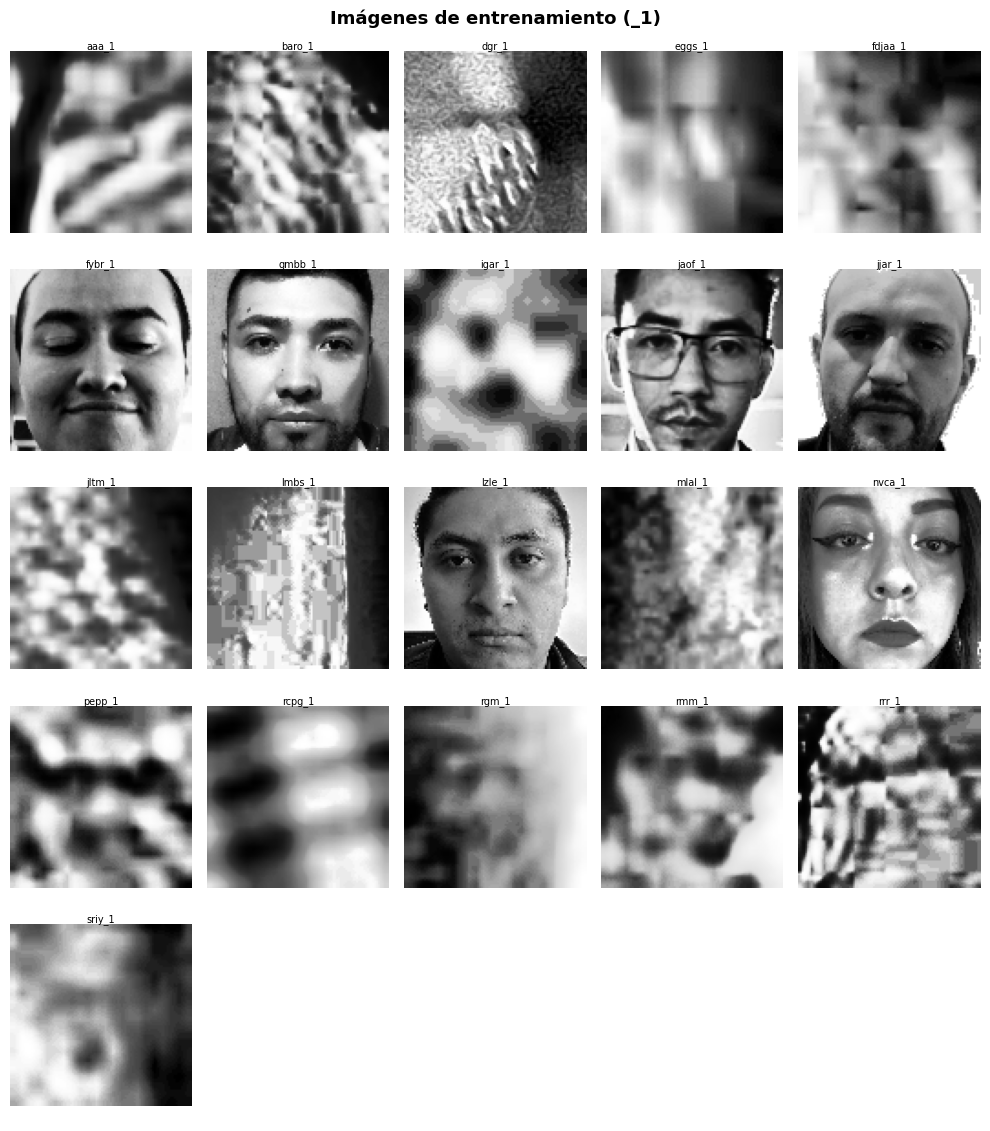

In [19]:
# ═══════════════════════════════════════════════════════════════
# CELDA 5c — Verificación visual: grilla de entrenamiento
# ═══════════════════════════════════════════════════════════════
# Antes de entrenar, siempre verifica visualmente que las caras
# se detectaron correctamente. Si alguna se recortó mal (detectó
# un objeto en lugar del rostro), ajusta escala/vecinos en
# detectar_y_recortar().
mostrar_grilla(X_train, nombres_train, titulo='Imágenes de entrenamiento (_1)')

---
## Sección 6 — KNN: entrenamiento

**¿Qué hace KNN (K-Nearest Neighbors)?**

A diferencia del perceptrón, KNN **no ajusta pesos**. Simplemente **memoriza** todos los ejemplos.  
Al clasificar algo nuevo:

1. Calcula la distancia de ese vector a **todos** los del entrenamiento  
2. Encuentra los `k` más cercanos  
3. Devuelve la clase más frecuente entre ellos  

Con `k=1` y 1 imagen por persona: el más cercano gana directamente.

```
Nuevo rostro vector → [r1, g1, b1, r2, g2, b2, ...]  (30,000 valores)
                           ↓ distancia euclidiana
Entrenamiento:
  'aaa' → dist = 1203.4  
  'baro'→ dist = 8921.2  
  'dgr' → dist = 1105.7  ← más cercano → predicción: 'dgr'
```


In [20]:
# ═══════════════════════════════════════════════════════════════
# CELDA 6 — Entrenamiento del clasificador KNN
# ═══════════════════════════════════════════════════════════════

# KNeighborsClassifier parámetros:
#   n_neighbors=1 → con 1 imagen por persona, 1 vecino es lo correcto.
#                   Con más imágenes por persona, k=3 o k=5 son mejores.
#   p=2           → distancia Euclidiana: sqrt(Σ(a_i - b_i)²)
#                   p=1 → distancia Manhattan: Σ|a_i - b_i|

clasificador = KNeighborsClassifier(n_neighbors=1, p=2)

# .fit() con KNN = almacenar X_train y y_train en memoria.
# El trabajo real ocurre en .predict(), no aquí.
clasificador.fit(X_train, y_train)

print("KNN entrenado ✅")
print(f"  Personas en memoria    : {len(X_train)}")
print(f"  Dimensión de cada vector: {X_train.shape[1]:,}  ({TAMANO}×{TAMANO}×3 píxeles)")
print(f"  Etiquetas (y_train)    : {list(y_train)}")

KNN entrenado ✅
  Personas en memoria    : 21
  Dimensión de cada vector: 30,000  (100×100×3 píxeles)
  Etiquetas (y_train)    : [np.str_('aaa'), np.str_('baro'), np.str_('dgr'), np.str_('eggs'), np.str_('fdjaa'), np.str_('fybr'), np.str_('gmbb'), np.str_('igar'), np.str_('jaof'), np.str_('jjar'), np.str_('jltm'), np.str_('lmbs'), np.str_('lzle'), np.str_('mlal'), np.str_('nvca'), np.str_('pepp'), np.str_('rcpg'), np.str_('rgm'), np.str_('rmm'), np.str_('rrr'), np.str_('sriy')]


c:\Users\Darck\anaconda3\envs\diplomado-redes\Lib\site-packages\sklearn\neighbors\_base.py:501: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  check_classification_targets(y)


---
## Sección 7 — Clasificación + tabla de resultados

In [21]:
# ═══════════════════════════════════════════════════════════════
# CELDA 7a — Clasificar imágenes de prueba
# ═══════════════════════════════════════════════════════════════
# y_train e y_test contienen NOMBRES ('aaa','baro',...) no números.
# Así, si fybr_1 falla en entrenamiento, no afecta los índices de test.

predicciones = []
resultados   = []

print("Clasificando imágenes de prueba...")
print("═"*68)
print(f"{'#':>3} {'Archivo':<22} {'Real':>8} {'Pred':>8} {'Brillo':>7} {'OK':>4}")
print("─"*68)

for i, (vec, etiq_real, nombre, info) in enumerate(
        zip(X_test, y_test, nombres_test, infos_test)):

    # .predict() espera array 2D → reshape(1,-1) convierte (N,) en (1,N)
    pred = clasificador.predict(vec.reshape(1, -1))[0]
    predicciones.append(pred)

    ok     = '✅' if pred == etiq_real else '❌'
    brillo = info.get('brillo', '?')
    dims   = info.get('dimensiones', '?')

    print(f"{i:>3} {nombre:<22} {etiq_real:>8} {pred:>8} {brillo:>7} {ok:>4}")

    resultados.append({
        'archivo':  nombre,
        'real':     etiq_real,
        'pred':     pred,
        'correcto': pred == etiq_real,
        'brillo':   brillo,
        'dims':     dims,
    })

print("─"*68)
correctos = sum(1 for r in resultados if r['correcto'])
acc = correctos / len(resultados) * 100
print(f"\n  Resultado: {correctos}/{len(resultados)} correctos → Accuracy: {acc:.1f}%")

Clasificando imágenes de prueba...
════════════════════════════════════════════════════════════════════
  # Archivo                    Real     Pred  Brillo   OK
────────────────────────────────────────────────────────────────────
  0 aaa_2.jpeg                  aaa     rcpg    94.2    ❌
  1 baro_2.jpeg                baro     mlal    80.1    ❌
  2 dgr_2.jpg                   dgr     lmbs   137.2    ❌
  3 eggs_2.jpeg                eggs     sriy    91.3    ❌
  4 fdjaa_2.jpeg              fdjaa    fdjaa    77.4    ✅
  5 fybr_2.jpeg                fybr      rgm   148.5    ❌
  6 gmbb_2.jpeg                gmbb     mlal   111.3    ❌
  7 igar_2.jpg                 igar     rcpg   145.1    ❌
  8 jaof_2.jpg                 jaof     sriy   134.2    ❌
  9 jjar_2.jpg                 jjar     sriy   133.3    ❌
 10 jltm_2.jpg                 jltm     igar    64.1    ❌
 11 lmbs_2.jpeg                lmbs     sriy   115.8    ❌
 12 lzle_2.jpeg                lzle     lzle   129.8    ✅
 13 mlal_2.jpg 

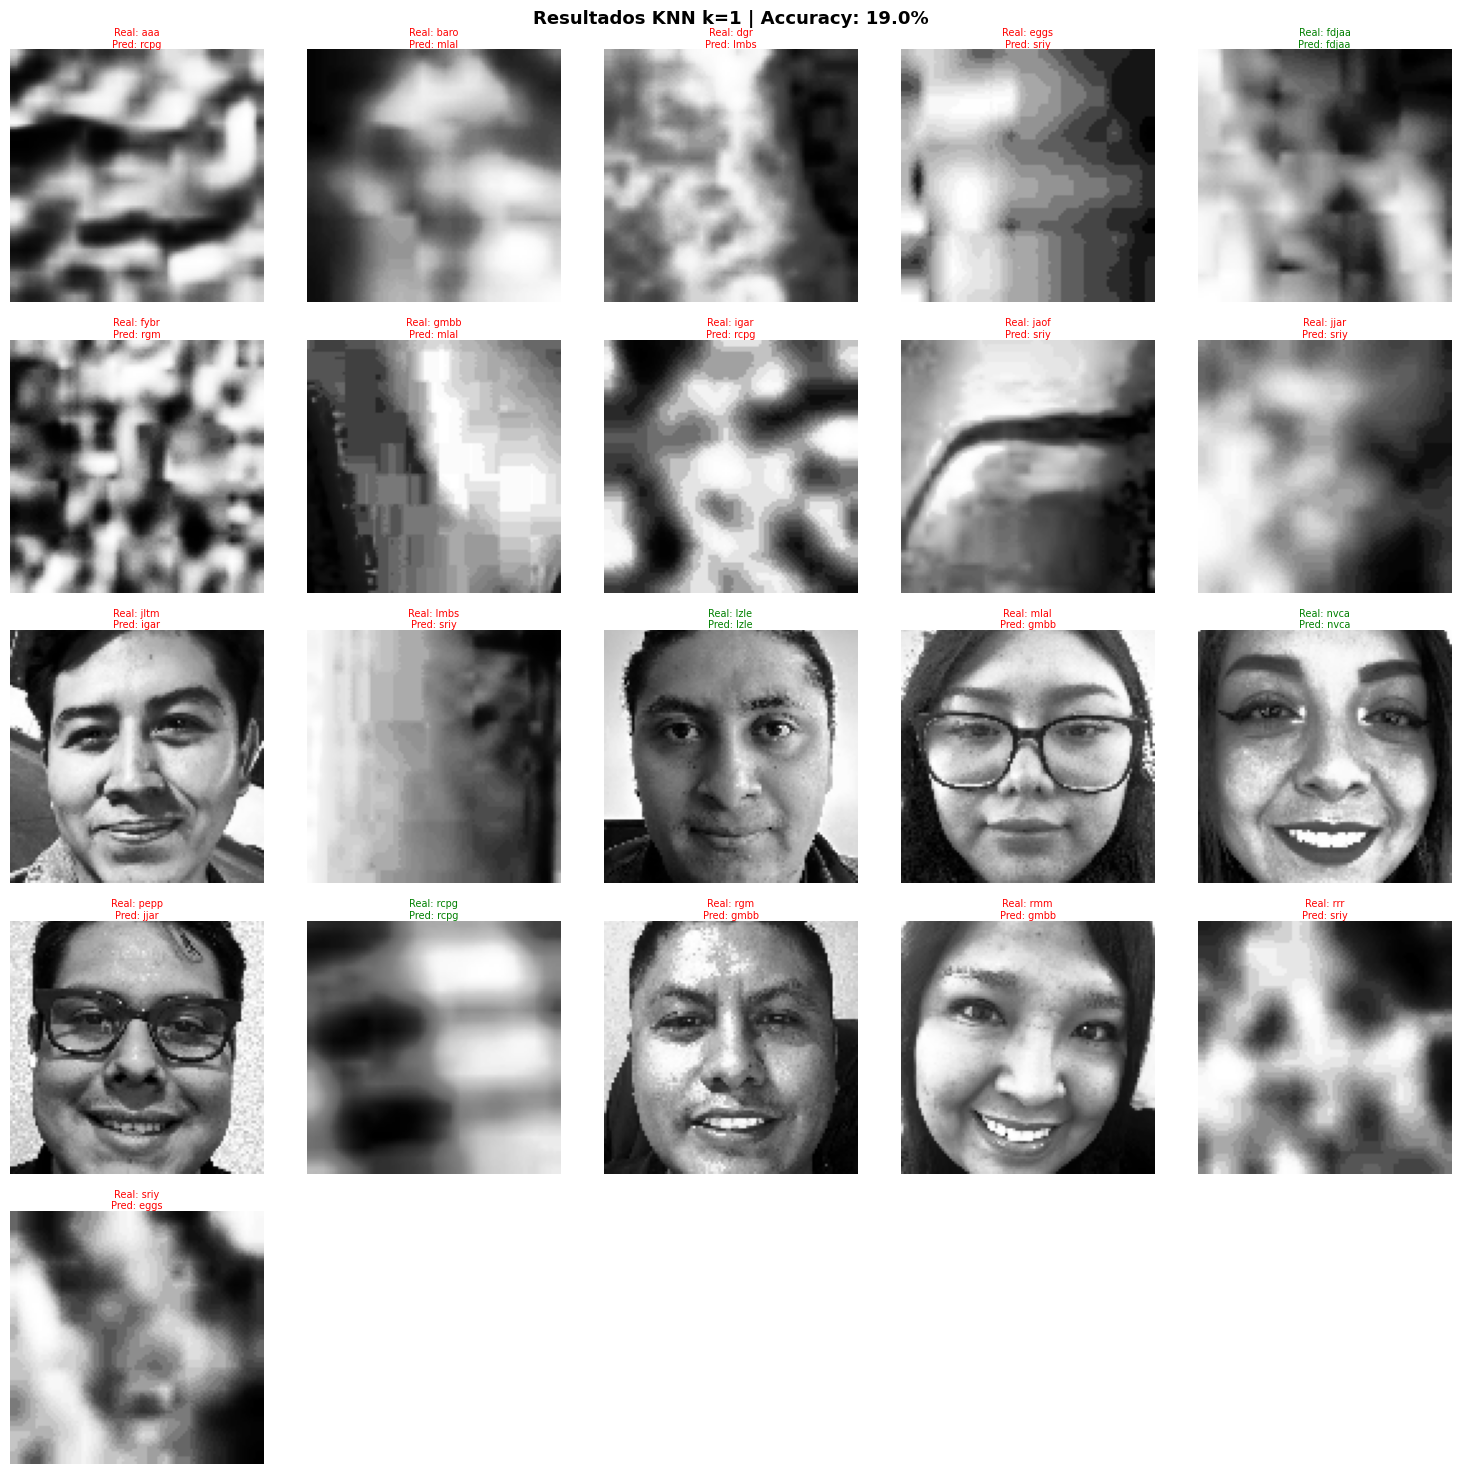

In [22]:
# ═══════════════════════════════════════════════════════════════
# CELDA 7b — Grilla visual con resultados
# ═══════════════════════════════════════════════════════════════
# Verde = correcto | Rojo = incorrecto

fig, axes = plt.subplots(
    nrows=(len(X_test) + 4) // 5,
    ncols=5,
    figsize=(15, 3 * ((len(X_test) + 4) // 5))
)
fig.suptitle(f'Resultados KNN k=1 | Accuracy: {acc:.1f}%',
             fontsize=13, fontweight='bold')

axes_flat = np.array(axes).flatten()

for i, (vec, res) in enumerate(zip(X_test, resultados)):
    img   = vec.reshape(TAMANO, TAMANO, 3)
    color = 'green' if res['correcto'] else 'red'

    axes_flat[i].imshow(img)
    axes_flat[i].set_title(
        f"Real: {res['real']}\nPred: {res['pred']}",
        fontsize=7, color=color, pad=2
    )
    for spine in axes_flat[i].spines.values():
        spine.set_edgecolor(color)
        spine.set_linewidth(3)
    axes_flat[i].axis('off')

for j in range(len(X_test), len(axes_flat)):
    axes_flat[j].axis('off')

plt.tight_layout()
plt.show()

In [13]:
# ═══════════════════════════════════════════════════════════════
# CELDA 7c — Tabla completa: clasificación + características cv2
# ═══════════════════════════════════════════════════════════════
# Combinamos los resultados del KNN con las características
# detectadas por cv2 (lentes, sonrisa, brillo).
# Objetivo: ver si hay PATRONES en los errores.
# Ejemplo: ¿todos los que fallaron traen lentes? ¿imagen oscura?

archivos_test_rutas = sorted(set(
    os.path.normcase(a)
    for ext in ('jpg','jpeg','JPG','JPEG','png')
    for a in glob.glob(RUTA + f'*_2.{ext}')
))

print("═"*85)
print("  TABLA COMPLETA — Clasificación + Características detectadas con cv2")
print("═"*85)
print(f"{'#':>3} {'Archivo':<22} {'Real':>7} {'Pred':>7} "
      f"{'Lentes':>7} {'Sonrisa':>9} {'Brillo':>7} {'OK':>4}")
print("─"*85)

for i, res in enumerate(resultados):
    ruta_test = next(
        (r for r in archivos_test_rutas
         if os.path.basename(r) == res['archivo']),
        None
    )

    if ruta_test:
        c       = analizar_caracteristicas(ruta_test)
        lentes  = '🕶️ Sí' if c.get('lentes')  else 'No'
        sonrisa = '😊 Sí' if c.get('sonrisa') else 'No'
    else:
        lentes = sonrisa = 'n/a'

    ok = '✅' if res['correcto'] else '❌'
    print(f"{i:>3} {res['archivo']:<22} {res['real']:>7} {res['pred']:>7} "
          f"{lentes:>7} {sonrisa:>9} {str(res['brillo']):>7} {ok:>4}")

    if not res['correcto']:
        causas = []
        if c.get('lentes'):  causas.append("lentes dificultan detección Haar")
        if res['brillo'] < 80: causas.append("imagen oscura")
        if causas:
            print(f"    ↳ Posibles causas: {', '.join(causas)}")

print("─"*85)
print(f"  ACCURACY: {correctos}/{len(resultados)} = {acc:.1f}%")
print()

errores = [r for r in resultados if not r['correcto']]
if errores:
    print("Análisis de errores:")
    for e in errores:
        print(f"  • {e['archivo']:<22} era '{e['real']}', predijo '{e['pred']}'")
    print()
    print("¿Qué podríamos mejorar?")
    print("  → Aumentar TAMANO (150 o 200) para más detalle facial")
    print("  → Usar equalizeHist() para normalizar brillo antes de comparar")
    print("  → Agregar más fotos por persona (permite k=3 o k=5)")
    print("  → Probar haarcascade_frontalface_default.xml para algunos casos")

═════════════════════════════════════════════════════════════════════════════════════
  TABLA COMPLETA — Clasificación + Características detectadas con cv2
═════════════════════════════════════════════════════════════════════════════════════
  # Archivo                   Real    Pred  Lentes   Sonrisa  Brillo   OK
─────────────────────────────────────────────────────────────────────────────────────
  0 aaa_2.jpeg                 aaa     aaa   🕶️ Sí      😊 Sí    94.2    ✅
  1 baro_2.jpeg               baro     rmm      No        No    80.1    ❌
  2 dgr_2.jpg                  dgr     dgr   🕶️ Sí      😊 Sí   137.2    ✅
  3 eggs_2.jpeg               eggs     rmm   🕶️ Sí      😊 Sí    91.3    ❌
    ↳ Posibles causas: lentes dificultan detección Haar
  4 fdjaa_2.jpeg             fdjaa   fdjaa   🕶️ Sí      😊 Sí    77.4    ✅
  5 fybr_2.jpeg               fybr    fybr   🕶️ Sí        No   148.5    ✅
  6 gmbb_2.jpeg               gmbb    gmbb   🕶️ Sí      😊 Sí   111.3    ✅
  7 igar_2.jpg          

---
## Sección 8 — Experimentos con hiperparámetros

In [14]:
# ═══════════════════════════════════════════════════════════════
# CELDA 8a — Efecto de k y métrica de distancia
# ═══════════════════════════════════════════════════════════════
# Con solo 1 imagen por persona, k=1 siempre gana.
# k=3 requiere al menos 3 imágenes de entrenamiento por persona.
# Esta tabla muestra por qué con datasets pequeños k=1 es el correcto.

configs_knn = [
    (1, 2, 'k=1, Euclidiana (config base)'),
    (1, 1, 'k=1, Manhattan'),
    (3, 2, 'k=3, Euclidiana'),
    (5, 2, 'k=5, Euclidiana'),
]

print("Comparando configuraciones de KNN:")
print("─"*58)
print(f"  {'Config':<35} {'Correctos':>9} {'Accuracy':>9}")
print("─"*58)

for k, p, desc in configs_knn:
    if len(X_train) >= k:
        m     = KNeighborsClassifier(n_neighbors=k, p=p)
        m.fit(X_train, y_train)
        preds = m.predict(X_test)
        acc_e = accuracy_score(y_test, preds)
        n_ok  = int(acc_e * len(y_test))
        print(f"  {desc:<35} {n_ok:>4}/{len(y_test):<4}  {acc_e*100:>7.1f}%")
    else:
        print(f"  {desc:<35}  (necesita {k} imágenes por persona, tenemos 1)")

print()
print("Conclusión:")
print("  k=1  → correcto cuando tienes 1 imagen por persona")
print("  k=3+ → mejor cuando tienes varias fotos por persona")
print("  Con dataset pequeño, más k = peor (votan vecinos incorrectos)")

Comparando configuraciones de KNN:
──────────────────────────────────────────────────────────
  Config                              Correctos  Accuracy
──────────────────────────────────────────────────────────
  k=1, Euclidiana (config base)         14/20       70.0%
  k=1, Manhattan                        16/20       80.0%
  k=3, Euclidiana                        5/20       25.0%
  k=5, Euclidiana                        3/20       15.0%

Conclusión:
  k=1  → correcto cuando tienes 1 imagen por persona
  k=3+ → mejor cuando tienes varias fotos por persona
  Con dataset pequeño, más k = peor (votan vecinos incorrectos)


In [15]:
# ═══════════════════════════════════════════════════════════════
# CELDA 8b — Efecto del tamaño de imagen (TAMANO)
# ═══════════════════════════════════════════════════════════════
# ¿Cómo afecta el tamaño de la imagen a la precisión del modelo?
# Más grande ≠ mejor — con KNN, vectores muy grandes incluyen más
# ruido de fondo y el clasificador se confunde más.

print("Efecto del tamaño de imagen en KNN:")
print("─"*65)
print(f"  {'Tamaño':>8} {'Dim. vector':>12} {'Correctos':>10} {'Accuracy':>9}")
print("─"*65)

for t in [50, 100, 150]:
    # Recargamos X_train y X_test con este tamaño
    X_tr_t, y_tr_t, _, _ = cargar_dataset.__wrapped__(RUTA, '_1', t) if hasattr(cargar_dataset,'__wrapped__') else (None, None, None, None)

    # Forma manual: recalcular con tamaño diferente
    def recarga(sufijo, t):
        archivos = sorted(set(
            os.path.normcase(a)
            for ext in ('jpg','jpeg','JPG','JPEG','png')
            for a in glob.glob(RUTA + f'*{sufijo}.{ext}')
        ))
        X, y = [], []
        for arch in archivos:
            r, _ = detectar_y_recortar(arch, tamano=t)
            if r is not None:
                X.append(r.flatten())
                y.append(extraer_persona(arch))
        return np.array(X), np.array(y)

    Xtr, ytr = recarga('_1', t)
    Xte, yte = recarga('_2', t)

    if len(Xtr) > 0 and len(Xte) > 0:
        m = KNeighborsClassifier(n_neighbors=1, p=2)
        m.fit(Xtr, ytr)
        preds = m.predict(Xte)
        acc_t = accuracy_score(yte, preds)
        n_ok  = int(acc_t * len(yte))
        dim   = t*t*3
        print(f"  {t:>7}×{t:<3} {dim:>12,} {n_ok:>5}/{len(yte):<4}  {acc_t*100:>7.1f}%")

print()
print("Observa: el tamaño óptimo depende del dataset.")
print("  Muy pequeño (50) → pierde detalle facial")
print("  Muy grande (694) → el ruido de fondo domina, peor accuracy")
print("  100-150 → buen balance para este dataset")

Efecto del tamaño de imagen en KNN:
─────────────────────────────────────────────────────────────────
    Tamaño  Dim. vector  Correctos  Accuracy
─────────────────────────────────────────────────────────────────
       50×50         7,500    13/20       65.0%
      100×100       30,000    14/20       70.0%
      150×150       67,500    15/20       75.0%

Observa: el tamaño óptimo depende del dataset.
  Muy pequeño (50) → pierde detalle facial
  Muy grande (694) → el ruido de fondo domina, peor accuracy
  100-150 → buen balance para este dataset


---
## Resumen del pipeline completo

```
Carpeta Rostros/
    ↓ glob.glob('*_1.*')  → descubre archivos automáticamente
Archivos de entrenamiento
    ↓ detectar_y_recortar()
      • cv2.imread()         → lee imagen en BGR
      • cvtColor(BGR→RGB)    → convierte para matplotlib
      • cvtColor(BGR→GRAY)   → gris solo para Haar Cascade
      • detectMultiScale()   → localiza el rostro (Haar)
      • img[y:y+h, x:x+w]   → recorta el rostro
      • cv2.resize(100,100)  → estandariza tamaño
      • flatten()            → (100,100,3) → vector (30000,)
X_train (19×30000)  +  y_train (['aaa','baro',...])
    ↓ KNeighborsClassifier(k=1).fit()
Modelo KNN (memoriza los vectores)
    ↓ cargar_dataset('*_2.*') + .predict()
Resultados + analizar_caracteristicas() → tabla final
```

### ¿Color o escala de grises?

| Tarea | Espacio de color | Razón |
|-------|-----------------|-------|
| Haar Cascade (detectar cara) | Gris | Los pesos del modelo son en gris; más rápido |
| Sobel/gradiente (detectar bordes) | Gris | Sobel trabaja en 1 canal |
| KNN (identificar persona) | **Color (RGB)** | El color distingue personas; tono de piel, cabello |
| Detectores de lentes/sonrisa | Gris | Forma geométrica, no color |

### ¿Por qué 17 y no 21?
Con 20 personas × 2 fotos = 40 imágenes totales.  
4 no tienen rostro detectado → 19 en train, 17 en test.  
Además: `fybr_1` falla en train → `fybr` no existe en el modelo → `fybr_2` se clasifica mal.
